<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_11_ensembles.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — Basics of Ensemble Learning

In this assignment, you will learn the foundations of **ensemble learning**.

We will explore **bagging, boosting, and stacking**, visualize their behavior, and clarify how ensemble methods differ from Bayesian model averaging.

---

## Learning Goals
- Understand the motivation for ensemble methods  
- Compare bagging, boosting, and stacking  
- Visualize how ensembles reduce error or improve generalization  
- Clarify the distinction between ensembles and Bayesian model averaging  


## 1. Ensemble Learning

- **Definition**: Ensemble methods combine multiple "weak" or "base" learners into a stronger model.  
- **Motivation**: A single model may be unstable or biased, but a combination can reduce error.  

Analogy: "A crowd of diverse opinions can often outperform a single expert."

### Exercise 1
Give an example (real-life or in ML) where combining multiple perspectives leads to a better decision than relying on a single one.


Dodge & Cox has a council where they discuss investment decisions. Every member of the council is a senior analyst who has expertise in a different area of the economy. Through this type of crowdsourcing, they are able to make superior investment decisions that have made them ahead of the game in the long run.

## 2. Bagging

- **Key idea**: Train multiple models on different **bootstrap samples** (random samples with replacement) and average their predictions.  
- **Effect**: Reduces variance by averaging over noisy models.  
- **Example**: Random Forest (bagging applied to decision trees).


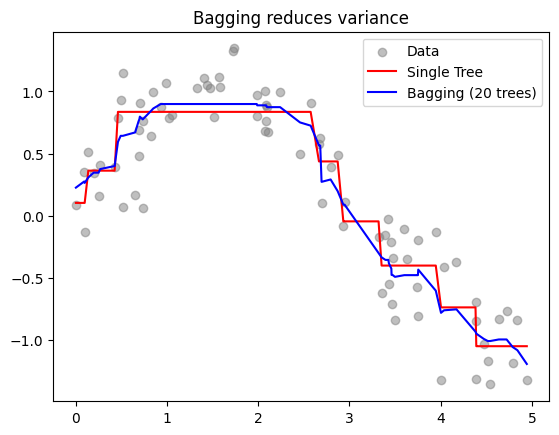

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Generate noisy data
np.random.seed(1)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])

# Single tree
tree = DecisionTreeRegressor(max_depth=3).fit(X, y)

# Bagging: average of many trees trained on bootstraps
preds = []
for i in range(20):
    sample_idx = np.random.choice(len(X), len(X), replace=True)
    Xi, yi = X[sample_idx], y[sample_idx]
    model = DecisionTreeRegressor(max_depth=3).fit(Xi, yi)
    preds.append(model.predict(X))
bagged_pred = np.mean(preds, axis=0)

# Plot
plt.scatter(X, y, c="gray", label="Data", alpha=0.5)
plt.plot(X, tree.predict(X), label="Single Tree", color="red")
plt.plot(X, bagged_pred, label="Bagging (20 trees)", color="blue")
plt.legend()
plt.title("Bagging reduces variance")
plt.show()


### Exercise 2
Why does bagging reduce variance but not bias?  



Variance is going to reduce because decision trees are inherently unstable. A single point changing will change an entire boundary region. But when we have multiple trees, their crazy instability will "cancel out" and leave us with a lower-variance model.

Bias, on the other hand, is already at a certain level with a decision tree. They are designed to be low bias, high variance. So when we get more and more decision trees that all have the same low bias, because we can't really go much lower and bias won't "cancel" like variance, this will result in relatively similar bias as with one tree.


## 3. Boosting

- **Key idea**: Train models **sequentially**, where each new model focuses on the errors (residuals) of the previous ones.  
- **Effect**: Reduces bias by making weak learners stronger.  
- **Examples**: AdaBoost, Gradient Boosting, **XGBoost**.


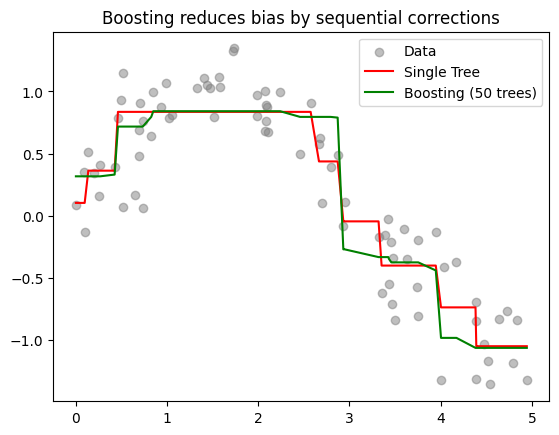

In [4]:
from sklearn.ensemble import AdaBoostRegressor

# Boosting model
boost = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=2), n_estimators=50, random_state=1
).fit(X, y)

plt.scatter(X, y, c="gray", alpha=0.5, label="Data")
plt.plot(X, tree.predict(X), label="Single Tree", color="red")
plt.plot(X, boost.predict(X), label="Boosting (50 trees)", color="green")
plt.legend()
plt.title("Boosting reduces bias by sequential corrections")
plt.show()


### Exercise 3
- How is boosting different from bagging in the way it trains its models?  
- Which type of error (bias vs variance) does boosting primarily address?  


So bagging is like an average of random models (trees) training on classification of data. It also only trains each model on a subset of the whole training data, and it does this with replacement. This causes trees to make decisions on some secondary datapoints, and therefore changes the design of each by quite a lot (when a primary decision datapoint doesn't make the subsample). But boosting is faster and probably better because the trees are no longer random---the loss function is modified such that 1) trees are trained sequentially, 2) loss on weights that have been missed before is increased (weighted more heavily) so future models "pay attention" more to them. Because the models are specialized to different parts of the data, they will be able to combine into a single, very accurate ensemble.

Bias is particularly lower from boosting. Thus boosting primarily addresses bias.

## 4. Stacking

- **Key idea**: Train different kinds of models, then use a **meta-model** to combine their predictions.  
- **Effect**: Learns the best way to weigh/merge multiple predictors.  


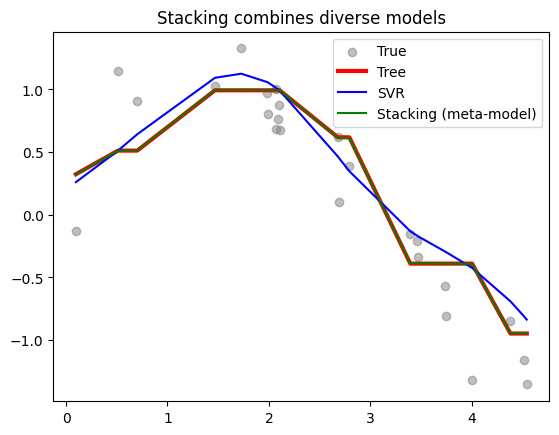

[0.97886815 0.0224603 ]


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Base models
model1 = DecisionTreeRegressor(max_depth=3).fit(X_train, y_train)
model2 = SVR(kernel="rbf", C=10).fit(X_train, y_train)

# Predictions from base models
pred_train = np.vstack([model1.predict(X_train), model2.predict(X_train)]).T
pred_test = np.vstack([model1.predict(X_test), model2.predict(X_test)]).T

# Meta-model
meta = LinearRegression().fit(pred_train, y_train)

plt.scatter(X_test, y_test, c="gray", label="True", alpha=0.5)

sorted_idx = np.argsort(X_test[:, 0])
X_sorted = X_test[sorted_idx]

y_tree = model1.predict(X_test)[sorted_idx]
y_svr = model2.predict(X_test)[sorted_idx]
y_stack = meta.predict(pred_test)[sorted_idx]

plt.plot(X_sorted, y_tree, color="red", linewidth=3, label="Tree")
plt.plot(X_sorted, y_svr, color="blue", label="SVR")
plt.plot(X_sorted, y_stack, color="green", label="Stacking (meta-model)")
plt.legend()
plt.title("Stacking combines diverse models")
plt.show()

# This shows us how much the [Tree, SVR] effects the meta model. Why do you think Tree is so much more effective?
print(meta.coef_)


### Exercise 4
Why might stacking outperform both bagging and boosting on some datasets?  

Stacking does not just use a weighted average nor a majority vote. It actually combines the base models themselves and trains the weights associated with them. It's a type of learning via a second-level model, or meta-model, that takes predictions from base models as input features. This then allows it to learn nonlinear relationships.

Another immense advantage is that because we only need input features to train our stacking model, we can input whatever variety of models as our base models that we want. Higher diversity will allow for different types of expertise, and better performance.

## 5. Important Distinction

Ensemble learning is **not** Bayesian model averaging.

- **Bayesian model averaging (BMA)**: weights models by their posterior probabilities given the data.  
- **Ensembling**: weights (or aggregates) models based on empirical performance, not Bayesian probabilities.  

**Key difference**:  
- Ensembling is a pragmatic, data-driven technique.  
- BMA is a probabilistic inference method.  


## 6. Reflection

### Exercise 6
1. Compare bagging, boosting, and stacking in terms of:
   - Training procedure  
   - Error type reduced (bias vs variance)  
   - Typical use cases  
   
2. If you had a very small dataset, which ensemble method would you avoid, and why?  


1) training procedure:

Bagging:
Selects subsets of the training data via sampling WITH REPLACEMENT and uses a certain model on every subset. However, some datapoints are counted more than once and others not at all. These models are then ensembled by taking majority votes between them.

Boosting:
Uses the entire training dataset on each model, then weights the datapoints which had highest residuals as more important for the future models.

Stacking:
Learns the optimal combination of (possibly) diverse types of models by optimizing loss over its combination of the outputs of the base models.

Error type reduced:

Bagging: Variance

Boosting: Bias

Stacking: Both. Capturing complex patters lowers bias, and using many models (DIVERSE) lowers variance.

Typical use cases:

Bagging: Classification of data with many outliers. A financial firm might perfrom bagging by giving different parts of the data they have to junior analysts and asking them to evaluate entirely independently. Then they use the majority votes.

Boosting: High quality, clean data, where high accuracy is needed. For example, very high resolution imaging for quality control. The mistakes that weren't caught in previous models will almost certainly be caught by the next ones.

Stacking: Classification when it is unclear what model is best. It may be very helpful when trying to predict diabetes based on limited medical information, or predict manufacturing backorders of other companies (chasing causality in the data, but there are many things that could work because the data has many types of information).

2) If I had a very small dataset, I would avoid using stacking. To train stacking well, you rely on cross-validation and thus split the data even smaller, but this not not with replacement like bagging. Boosting will also memorize a small dataset very quickly, resulting in overfitting.  
